# AnalystLab Africa — Machine Learning Internship
## Week 1: Machine Learning Problem Framing & Data Understanding
### Project: Customer Churn Prediction — ABC Communications Ltd

**Prepared by:** Junior Machine Learning Engineer, AnalystLab Africa Consulting
**Dataset:** [Telco Customer Churn (Kaggle / IBM Sample Data Sets)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

This notebook covers Parts 2–5 of the Week 1 assignment: dataset inspection, problem framing, exploratory data analysis, and model planning.


## Part 2 — Dataset Inspection

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("Telco-Customer-Churn.csv")
print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# Data types
df.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [18]:
# Missing values
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**Note:** A plain `isna().sum()` shows zero missing values everywhere. However, `TotalCharges` is stored as an `object` (text) column even though it should be numeric. This hides missing values encoded as empty strings `" "` rather than `NaN`. We check for this below.

In [19]:
# Hidden missing values in TotalCharges (stored as text)
blank_mask = df['TotalCharges'].str.strip() == ''
print("Rows with blank TotalCharges:", blank_mask.sum())
df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


All 11 affected rows have `tenure = 0`, i.e. brand-new customers with no billing history yet. This is a logical data-entry gap, not a random error: with zero months of tenure there is nothing to sum into a total charge. We convert the column to numeric and fill these 11 rows with `0` (equivalent to `tenure × MonthlyCharges` in this case).

In [20]:
# Fix TotalCharges: convert to numeric, fill the 11 blank rows with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("TotalCharges dtype after fix:", df['TotalCharges'].dtype)
print("Remaining nulls:", df['TotalCharges'].isna().sum())


TotalCharges dtype after fix: float64
Remaining nulls: 0


In [21]:
# Duplicate check
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customerID values:", df['customerID'].duplicated().sum())


Fully duplicated rows: 0
Duplicated customerID values: 0


In [22]:
# Target variable distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(2))


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Summary — Part 2:**
- 7,043 unique customers, 21 columns, no fully missing values and no duplicate rows or IDs.
- `TotalCharges` was mis-typed as text and contained 11 hidden blanks, all belonging to customers with `tenure = 0`; fixed by converting to numeric and filling with 0.
- The target `Churn` is imbalanced: ~73.5% "No" vs ~26.5% "Yes" — this will drive our choice of evaluation metrics in Part 5.


## Part 3 — Problem Framing

**Business problem:** Predict, ahead of time, which customers are likely to churn so ABC Communications can target retention offers instead of reacting after the customer has already left.

**Target variable:** `Churn` (Yes/No) → binary classification problem.

**Input features:** All columns except `customerID` (a unique identifier with no predictive value) and `Churn` (the target itself).


In [23]:
target = 'Churn'
drop_cols = ['customerID', target]

categorical_features = df.drop(columns=drop_cols).select_dtypes(include='object').columns.tolist()
numerical_features = df.drop(columns=drop_cols).select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Numerical features ({len(numerical_features)}):", numerical_features)
print(f"\nCategorical features ({len(categorical_features)}):", categorical_features)


Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\netha\AppData\Local\Temp\ipykernel_14264\4054061065.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.drop(columns=drop_cols).select_dtypes(include='object').columns.tolist()


**Preprocessing requirements identified:**
| Step | Reason |
|---|---|
| Drop `customerID` | Unique identifier, no predictive signal, risk of leakage/overfitting |
| Fix `TotalCharges` dtype + impute 11 blanks | Already done in Part 2 |
| Encode binary categoricals (`Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn`, `gender`) | Map Yes/No (and gender) to 0/1 |
| One-hot encode multi-class categoricals (`InternetService`, `Contract`, `PaymentMethod`, `MultipleLines`, `OnlineSecurity`, etc.) | These have 3+ categories, not ordinal |
| Scale numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) | Needed for distance-based / regularized models (Logistic Regression, KNN, SVM); tree-based models don't strictly need it |
| Train/test split (stratified on `Churn`) | Preserve the 73.5/26.5 class balance in both sets |
| Address class imbalance | e.g. `class_weight='balanced'`, or SMOTE oversampling on the training set only |


## Part 4 — Exploratory Data Analysis
Required: at least 3 bar charts, 2 histograms, and 1 correlation heatmap.

### Bar Chart 1 — Churn count by Contract type

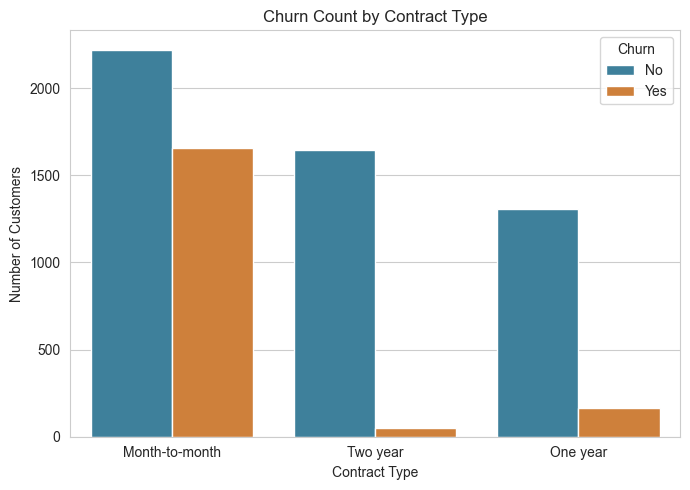

In [24]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Contract', hue='Churn', order=df['Contract'].value_counts().index,
              palette={'No': '#2E86AB', 'Yes': '#E67E22'})
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


**Insight:** Month-to-month contracts show a far higher churn count than one- or two-year contracts — contract length looks like a strong churn driver.

### Bar Chart 2 — Churn count by Internet Service type

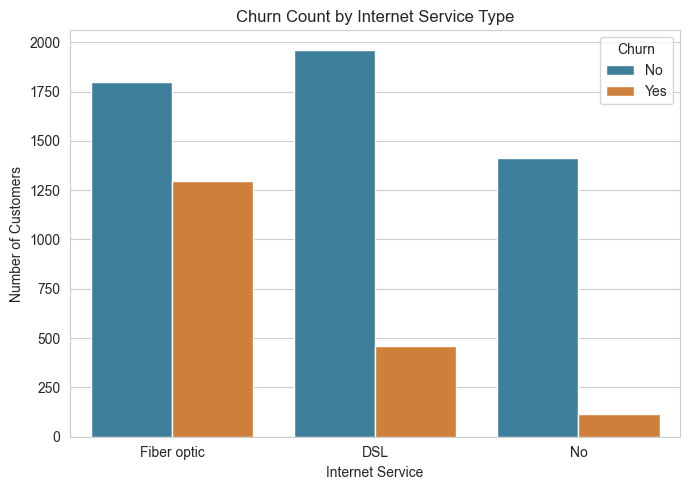

In [25]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='InternetService', hue='Churn', order=df['InternetService'].value_counts().index,
              palette={'No': '#2E86AB', 'Yes': '#E67E22'})
plt.title('Churn Count by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


**Insight:** Fiber optic customers churn more than DSL or no-internet customers — worth investigating pricing or service quality for fiber.

### Bar Chart 3 — Churn rate (%) by Payment Method

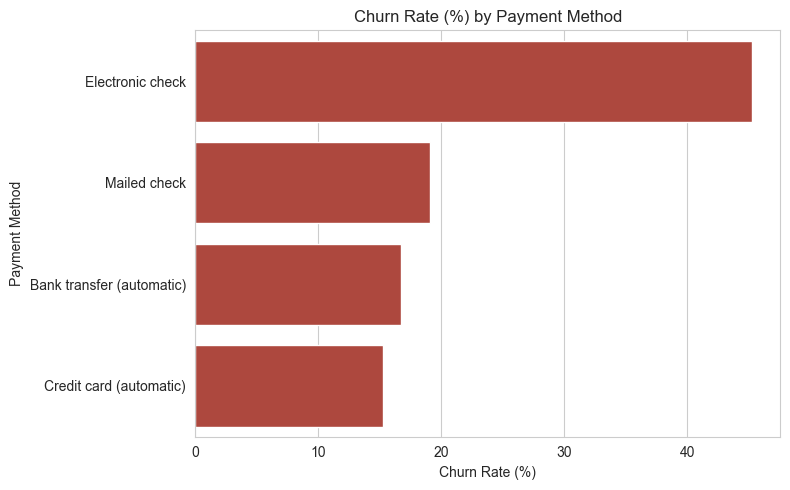

In [26]:
churn_by_payment = (df.groupby('PaymentMethod')['Churn']
                       .apply(lambda x: (x == 'Yes').mean() * 100)
                       .sort_values(ascending=False))

plt.figure(figsize=(8,5))
sns.barplot(x=churn_by_payment.values, y=churn_by_payment.index, color='#C0392B')
plt.title('Churn Rate (%) by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()


**Insight:** Customers paying by electronic check churn at a noticeably higher rate than those on automatic bank transfer or credit card payments — manual/less-automated payment methods correlate with higher churn.

### Histogram 1 — Tenure distribution

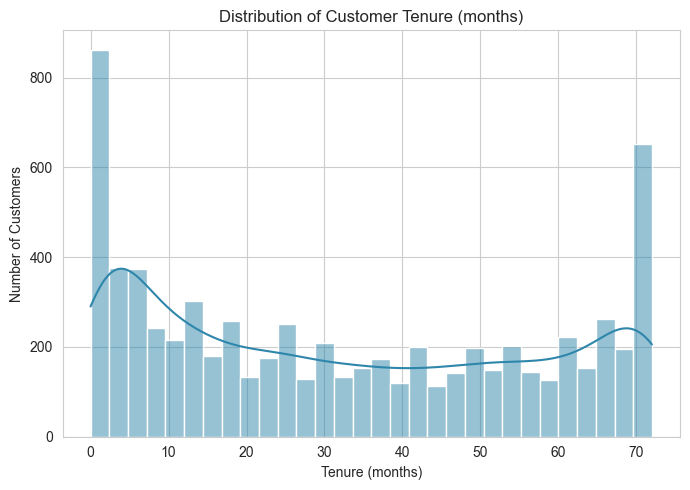

In [27]:
plt.figure(figsize=(7,5))
sns.histplot(df['tenure'], bins=30, kde=True, color='#2E86AB')
plt.title('Distribution of Customer Tenure (months)')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


**Insight:** The distribution is bimodal — a large spike of very new customers (0–5 months) and another spike near 70+ months (long-term loyal customers), with fewer customers in between.

### Histogram 2 — Monthly Charges distribution

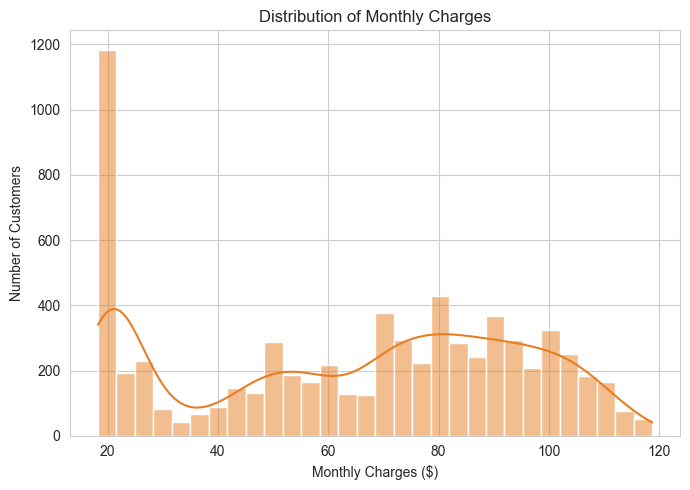

In [28]:
plt.figure(figsize=(7,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='#E67E22')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


**Insight:** Monthly charges cluster at the low end (~$20, mostly phone-only customers) and again in the $70–$100 range (bundled internet + add-on services).

### Correlation Heatmap — Numerical features

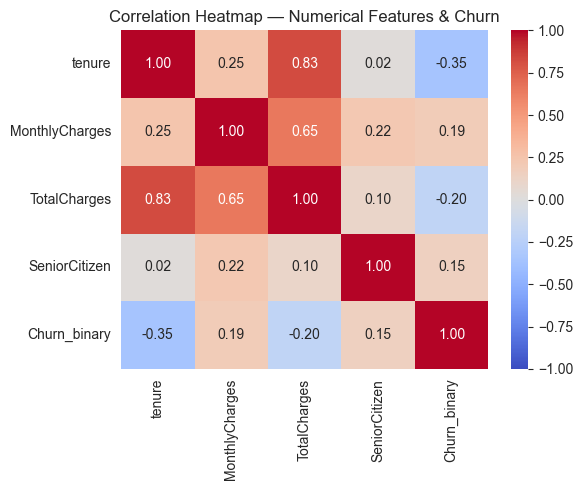

In [29]:
corr_df = df.copy()
corr_df['Churn_binary'] = (corr_df['Churn'] == 'Yes').astype(int)
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']

plt.figure(figsize=(6,5))
sns.heatmap(corr_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numerical Features & Churn')
plt.tight_layout()
plt.show()


**Insight:** `tenure` has the strongest (negative) correlation with churn — longer-tenured customers are less likely to leave. `TotalCharges` correlates strongly with `tenure` itself (expected, since it accumulates over time), while `MonthlyCharges` has a weaker positive correlation with churn.

## Part 5 — Model Planning

**Recommended evaluation metrics:**
Because `Churn` is imbalanced (~73.5% No / ~26.5% Yes), accuracy alone is misleading — a model that always predicts "No" would already score ~73.5% accuracy while being useless. We recommend:
- **Recall** — how many actual churners the model catches (critical: missing a churner is costly).
- **Precision** — how many predicted churners actually churn (retention offers aren't wasted on false positives).
- **F1-score** — balances precision and recall.
- **ROC-AUC** — overall ability to separate the two classes, threshold-independent.

**Recommended algorithms:**
| Algorithm | Why |
|---|---|
| Logistic Regression | Simple, fast, interpretable — good baseline and easy to explain churn drivers to the client |
| Random Forest | Captures non-linear interactions, provides feature importance |
| Gradient Boosting (XGBoost / LightGBM) | Typically the strongest performer on tabular data like this |
| (Optional comparison) KNN / SVM | Useful as a sanity-check baseline, less common for production tabular churn models |

**Recommended approach:** Start with Logistic Regression as an interpretable baseline, then compare against Random Forest and Gradient Boosting, selecting the final model on F1/ROC-AUC (not raw accuracy) on a held-out, stratified test set.


## Summary

| Question | Answer |
|---|---|
| Business problem | Predict customers likely to churn so ABC Communications can act proactively |
| Target variable | `Churn` (Yes/No) |
| Problem type | Binary classification |
| Key preprocessing | Fix `TotalCharges` dtype, encode categoricals, scale numerics, handle class imbalance |
| Evaluation metrics | Recall, Precision, F1-score, ROC-AUC (not accuracy alone) |
| Candidate algorithms | Logistic Regression (baseline), Random Forest, Gradient Boosting |

*Next week: train and validate these candidate models on the preprocessed dataset.*
